Financial Metrics with PyNance

[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed


📊 Financial Metrics:

        Cumulative Return  Annual Return  Volatility  Sharpe Ratio  \
Ticker                                                               
AAPL             1.419852       0.296534    0.254964      1.163043   
AMZN             2.124447       0.391107    0.317930      1.230168   
GOOGL            3.526162       0.497627    0.303683      1.638638   
MSFT             0.747891       0.196554    0.243358      0.807672   
TSLA             3.123821       0.590555    0.581052      1.016355   

        Max Drawdown      Beta  
Ticker                          
AAPL       -0.333605  1.140256  
AMZN       -0.308766  1.417856  
GOOGL      -0.298059  1.182188  
MSFT       -0.339101  1.011406  
TSLA       -0.537657  2.210897  


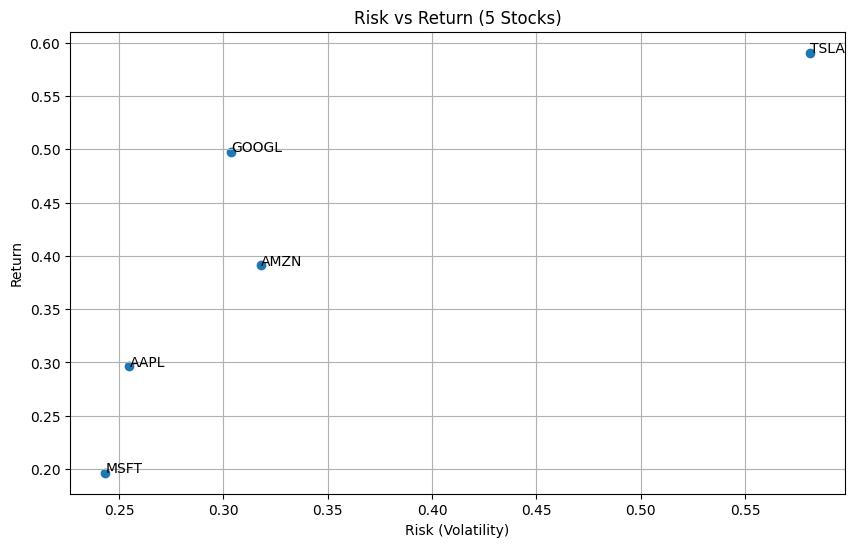

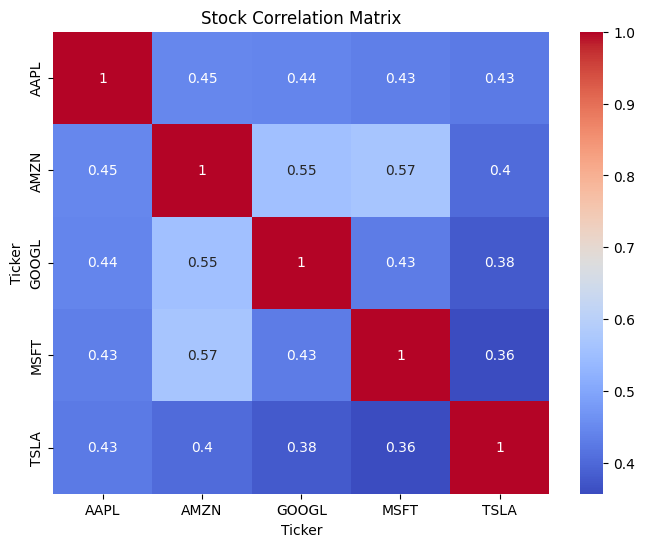

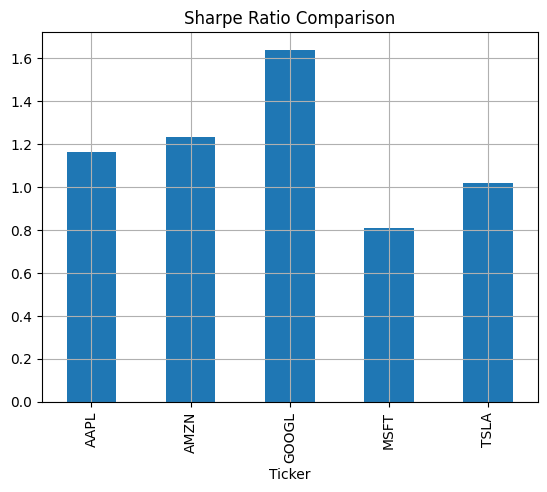

In [10]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# 1. Load Data
# ---------------------------
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]

prices = yf.download(tickers, start="2023-01-01")["Close"]

# ---------------------------
# 2. Returns
# ---------------------------
returns = prices.pct_change().dropna()

# ---------------------------
# 3. Financial Metrics
# ---------------------------

# Cumulative return
cumulative_return = (1 + returns).cumprod().iloc[-1] - 1

# Annual return
annual_return = returns.mean() * 252

# Volatility
volatility = returns.std() * np.sqrt(252)

# Sharpe ratio
sharpe_ratio = annual_return / volatility

# Max drawdown
cumulative = (1 + returns).cumprod()
peak = cumulative.cummax()
drawdown = (cumulative - peak) / peak
max_drawdown = drawdown.min()

# Beta vs SPY
market = yf.download("SPY", start="2023-01-01")["Close"].pct_change().dropna()

aligned = returns.join(market, how="inner")
beta = aligned.cov().loc[tickers, "SPY"] / aligned["SPY"].var()

# Correlation matrix
correlation = returns.corr()

# ---------------------------
# 4. Metrics Table
# ---------------------------
metrics = pd.DataFrame({
    "Cumulative Return": cumulative_return,
    "Annual Return": annual_return,
    "Volatility": volatility,
    "Sharpe Ratio": sharpe_ratio,
    "Max Drawdown": max_drawdown,
    "Beta": beta
})

print("\n📊 Financial Metrics:\n")
print(metrics)

# ---------------------------
# 5. Visualization: Risk vs Return
# ---------------------------
plt.figure(figsize=(10,6))
plt.scatter(metrics["Volatility"], metrics["Annual Return"])

for i in metrics.index:
    plt.text(metrics["Volatility"][i], metrics["Annual Return"][i], i)

plt.xlabel("Risk (Volatility)")
plt.ylabel("Return")
plt.title("Risk vs Return (5 Stocks)")
plt.grid()
plt.show()

# ---------------------------
# 6. Visualization: Correlation Heatmap
# ---------------------------
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Stock Correlation Matrix")
plt.show()

# ---------------------------
# 7. Visualization: Sharpe Ratio
# ---------------------------
metrics["Sharpe Ratio"].plot(kind="bar", title="Sharpe Ratio Comparison")
plt.grid()
plt.show()

In [11]:
import yfinance as yf
import pandas as pd
import numpy as np

tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "TSLA"]

prices = yf.download(tickers, start="2023-01-01")["Close"]
returns = prices.pct_change().dropna()

market = yf.download("SPY", start="2023-01-01")["Close"].pct_change().dropna()

# Align dates properly
aligned = returns.join(market, how="inner")

beta = {}

for col in tickers:
    cov = np.cov(aligned[col], aligned["SPY"])[0][1]
    var = np.var(aligned["SPY"])
    beta[col] = cov / var

beta = pd.Series(beta)

print(beta)

[*********************100%***********************]  5 of 5 completed
[*********************100%***********************]  1 of 1 completed

AAPL     1.141606
MSFT     1.012624
GOOGL    1.183584
AMZN     1.419534
TSLA     2.213516
dtype: float64
